In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
titanic = pd.read_csv('C:\\Users\\User\\OneDrive\\Desktop\\ML Lab 3-1\\Datasets\\titanic.csv')

In [5]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
titanic.shape

(891, 12)

In [7]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [8]:
titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [9]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
null_count = titanic["Age"].isnull().sum()
print(null_count)

177


In [13]:
age_mean = titanic["Age"].mean()
print(age_mean)

29.69911764705882


In [15]:
age_median = titanic["Age"].median()
print(age_median)

28.0


In [16]:
age_mode = titanic["Age"].mode()
print(age_mode)

0    24.0
Name: Age, dtype: float64


In [27]:
print("Mean   :", titanic["Age"].mean())
print("Median :", titanic["Age"].median())
print("Mode   :", titanic["Age"].mode().values)

Mean   : 29.69911764705882
Median : 28.0
Mode   : [24.]


In [17]:
age_variance = titanic["Age"].var()

print("Variance:", age_variance)

Variance: 211.01912474630802


In [18]:
age_std = titanic["Age"].std()

print("Standard Deviation:", age_std)

Standard Deviation: 14.526497332334042


In [19]:
Q1 = titanic["Age"].quantile(0.25)
print("Q1: ",Q1)

Q1:  20.125


In [22]:
Q2 = titanic["Age"].quantile(0.50)

print("Q2: ", Q2)

Q2:  28.0


In [24]:
Q3 = titanic["Age"].quantile(0.75)

print("Q3: ", Q3)

Q3:  38.0


In [26]:
IQR = Q3 - Q1
print("Interquartile Range:", IQR)

Interquartile Range: 17.875


In [28]:
print("Variance              :", titanic["Age"].var())
print("Standard Deviation    :", titanic["Age"].std())
print("Q1 (25%)              :", titanic["Age"].quantile(0.25))
print("Q2 (Median)           :", titanic["Age"].quantile(0.50))
print("Q3 (75%)              :", titanic["Age"].quantile(0.75))
print("Interquartile Range   :", titanic["Age"].quantile(0.75) - titanic["Age"].quantile(0.25))

Variance              : 211.01912474630802
Standard Deviation    : 14.526497332334042
Q1 (25%)              : 20.125
Q2 (Median)           : 28.0
Q3 (75%)              : 38.0
Interquartile Range   : 17.875


In [29]:
lower_limit = Q1 - 1.5 * IQR

print("Lower Limit:", lower_limit)

Lower Limit: -6.6875


In [30]:
upper_limit = Q3 + 1.5 * IQR

print("Upper Limit:", upper_limit)

Upper Limit: 64.8125


In [31]:
outliers = titanic[
    (titanic["Age"] < lower_limit) |
    (titanic["Age"] > upper_limit)
]

outliers

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
456,457,0,1,"Millet, Mr. Francis Davis",male,65.0,0,0,13509,26.5500,E38,S
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S


In [33]:
print("No. of Outliers: ",len(outliers))

No. of Outliers:  11


In [34]:
cleaned_data = titanic[
    (titanic["Age"] >= lower_limit) &
    (titanic["Age"] <= upper_limit)
]
cleaned_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [35]:
print("Original Mean:", titanic["Age"].mean())
print("Cleaned Mean:", cleaned_data["Age"].mean())

Original Mean: 29.69911764705882
Cleaned Mean: 29.07207681365576


In [36]:
print("Original Std:", titanic["Age"].std())

print("Cleaned Std:", cleaned_data["Age"].std())

Original Std: 14.526497332334042
Cleaned Std: 13.728477710187153


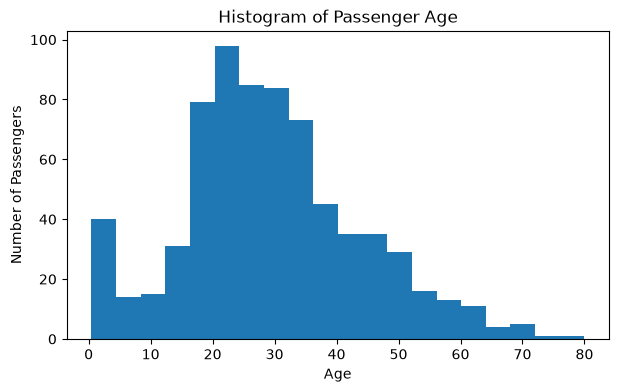

In [39]:
plt.figure(figsize=(7,4))

plt.hist(titanic["Age"].dropna(), bins=20)

plt.title("Histogram of Passenger Age")

plt.xlabel("Age")

plt.ylabel("Number of Passengers")

plt.show()

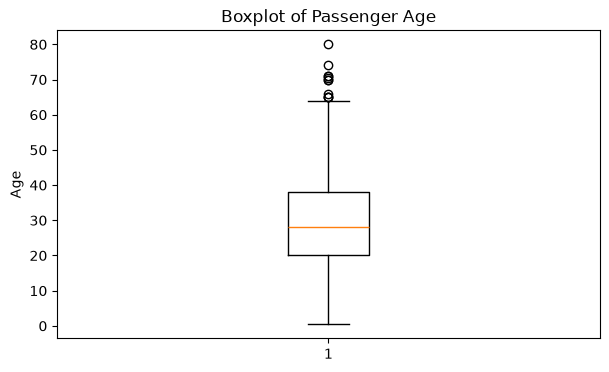

In [41]:
plt.figure(figsize=(7,4))

plt.boxplot(titanic["Age"].dropna())

plt.title("Boxplot of Passenger Age")

plt.ylabel("Age")

plt.show()

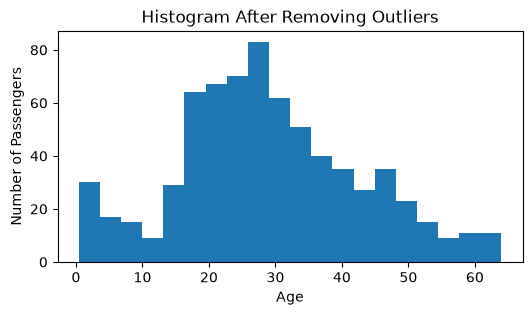

In [42]:
plt.figure(figsize=(6,3))

plt.hist(cleaned_data["Age"].dropna(), bins=20)

plt.title("Histogram After Removing Outliers")

plt.xlabel("Age")

plt.ylabel("Number of Passengers")

plt.show()

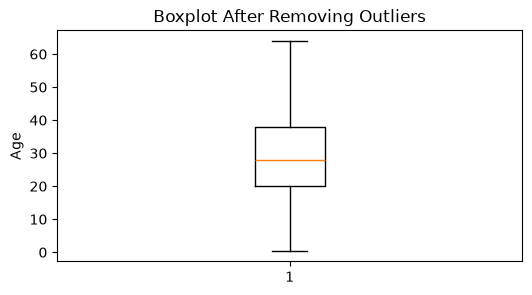

In [44]:
plt.figure(figsize=(6,3))

plt.boxplot(cleaned_data["Age"].dropna())

plt.title("Boxplot After Removing Outliers")

plt.ylabel("Age")

plt.show()

In [45]:
summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Variance",
        "Standard Deviation",
        "Q1",
        "Q2",
        "Q3",
        "IQR"
    ],
    "Age": [
        titanic["Age"].mean(),
        titanic["Age"].median(),
        titanic["Age"].mode()[0],
        titanic["Age"].var(),
        titanic["Age"].std(),
        titanic["Age"].quantile(0.25),
        titanic["Age"].quantile(0.50),
        titanic["Age"].quantile(0.75),
        titanic["Age"].quantile(0.75) - titanic["Age"].quantile(0.25)
    ]
})

summary

,Statistic,Age
0,Mean,29.699118
1,Median,28.000000
2,Mode,24.000000
3,Variance,211.019125
4,Standard Deviation,14.526497
5,Q1,20.125000
6,Q2,28.000000
7,Q3,38.000000
8,IQR,17.875000


In [50]:
cleaned_data.to_csv('C:\\Users\\User\\OneDrive\\Desktop\\ML Lab 3-1\\Output\\titanic_cleaned.csv', index=False)

In [52]:
summary.to_csv("C:\\Users\\User\\OneDrive\\Desktop\\ML Lab 3-1\\Output\\titanic_statistics.csv", index=False)

In [54]:
import pandas as pd

column_names = [
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth",
    "Species"
]

iris = pd.read_csv(
    "C:\\Users\\User\\OneDrive\\Desktop\\ML Lab 3-1\\Datasets\\iris.csv",
    header=None,
    names=column_names
)

In [55]:
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [56]:
iris.shape

(150, 5)

In [57]:
iris.columns

Index(['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species'], dtype='str')

In [58]:
iris.dtypes

SepalLength    float64
SepalWidth     float64
PetalLength    float64
PetalWidth     float64
Species            str
dtype: object

In [59]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Species      150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [60]:
iris.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [62]:
null_count = iris["PetalLength"].isnull().sum()
print(null_count)

0


In [63]:
print("Mean :", iris["PetalLength"].mean())

print("Median :", iris["PetalLength"].median())

print("Mode :", iris["PetalLength"].mode().values)

Mean : 3.758666666666666
Median : 4.35
Mode : [1.5]


In [64]:
print("Variance :", iris["PetalLength"].var())

print("Standard Deviation :", iris["PetalLength"].std())

Variance : 3.113179418344519
Standard Deviation : 1.7644204199522626


In [65]:
Q1 = iris["PetalLength"].quantile(0.25)

Q2 = iris["PetalLength"].quantile(0.50)

Q3 = iris["PetalLength"].quantile(0.75)

print("Q1 :", Q1)

print("Q2 :", Q2)

print("Q3 :", Q3)

Q1 : 1.6
Q2 : 4.35
Q3 : 5.1


In [66]:
IQR = Q3 - Q1

print("IQR :", IQR)

IQR : 3.4999999999999996


In [67]:
lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

print("Lower Limit :", lower_limit)

print("Upper Limit :", upper_limit)

Lower Limit : -3.649999999999999
Upper Limit : 10.349999999999998


In [68]:
outliers = iris[
    (iris["PetalLength"] < lower_limit) |
    (iris["PetalLength"] > upper_limit)
]

outliers

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species


In [69]:
print("Number of Outliers :", len(outliers))

Number of Outliers : 0


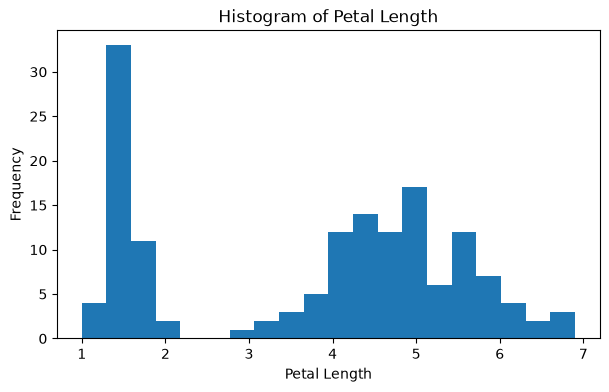

In [70]:
plt.figure(figsize=(7,4))

plt.hist(iris["PetalLength"], bins=20)

plt.title("Histogram of Petal Length")

plt.xlabel("Petal Length")

plt.ylabel("Frequency")

plt.show()

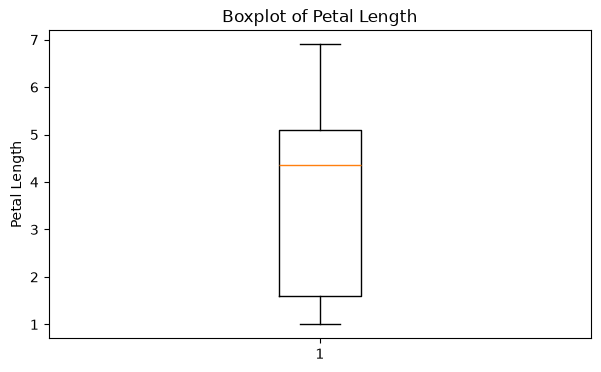

In [71]:
plt.figure(figsize=(7,4))

plt.boxplot(iris["PetalLength"])

plt.title("Boxplot of Petal Length")

plt.ylabel("Petal Length")

plt.show()

In [72]:
summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Variance",
        "Standard Deviation",
        "Q1",
        "Q2",
        "Q3",
        "IQR"
    ],
    "PetalLength": [
        iris["PetalLength"].mean(),
        iris["PetalLength"].median(),
        iris["PetalLength"].mode()[0],
        iris["PetalLength"].var(),
        iris["PetalLength"].std(),
        Q1,
        Q2,
        Q3,
        IQR
    ]
})

summary

,Statistic,PetalLength
0,Mean,3.758667
1,Median,4.350000
2,Mode,1.500000
3,Variance,3.113179
4,Standard Deviation,1.764420
5,Q1,1.600000
6,Q2,4.350000
7,Q3,5.100000
8,IQR,3.500000


In [73]:
summary.to_csv("C:\\Users\\User\\OneDrive\\Desktop\\ML Lab 3-1\\Output\\iris_statistics.csv", index=False)